# Multi-Variable Phenotype Clustering Analysis
## Chen 2004 Yeast Cell Cycle Model - Whole Network Phenotypes

This notebook implements the second definition of phenotype that considers the whole gene regulatory network rather than a single molecule. We use BIRCH clustering to group mn-dimensional points representing the full system output.

In [273]:

# Set model_path variable used later in the notebook
import os


# === IMPORTS ===
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import multiprocessing as mp
from multiprocessing import Pool, cpu_count, Manager
from functools import partial
import psutil
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import StandardScaler
import pandas as pd
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample
import scipy.stats as stats
from scipy.spatial.distance import cdist


# --- Config (tweak these) ---
SAMPLE_FOR_NN = 2000         # subset size to estimate NN distances
PCA_N_COMPONENTS = 0.95
SCALE = True
WHITEN=False      # keep 95% variance; or set int like 50
THRESHOLD_CANDIDATES_QUANTILES = [10, 25, 50, 75]  # percentiles to try for threshold
BRANCHING_FACTOR = 50
N_SILHOUETTE_SAMPLE = 5000   # sample size to compute silhouette (for speed)
RANDOM_STATE = 0
PCAreduction = False
CLB2_ONLY = True  # only use CLB2 trajectory for clustering


# Configuration
model_path = get_model_path()
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
SIMULATION_TIME = 500
SIMULATION_START = 100
N_TIME_POINTS = 300  # Discretize to 50 time points as per paper
SAMPLE_SIZE = 10**4  # 100K samples for initial testing
DIVERGENCE_THRESHOLD = 250

# Performance optimization settings
USE_MODEL_REUSE = True              # Reuse single model instance
BATCH_SIZE = 1000                   # Process in batches
ENABLE_FAST_REJECT = True           # Quick rejection of divergent solutions
REDUCED_PRECISION = True            # Use reduced simulation precision for speed

# === CPU PARALLELIZATION SETTINGS ===
USE_MULTIPROCESSING = True          # Enable multiprocessing
# Fallback: use (logical cores - 1) initially; detect_cpu_config() will update OPTIMAL_WORKERS/IS_AMD_CPU later
NUM_WORKERS = max(1, cpu_count() - 1)       # Number of parallel workers (fallback)
CHUNK_SIZE = max(100, SAMPLE_SIZE // (NUM_WORKERS * 10))  # Dynamic chunk size
USE_PROCESS_POOL = True             # Use ProcessPoolExecutor
ENABLE_MEMORY_OPTIMIZATION = True   # Enable memory optimization

# AMD/Radeon specific optimizations (guarded; may be updated by detect_cpu_config)
IS_AMD_CPU = False
if IS_AMD_CPU:
    CHUNK_SIZE = max(50, CHUNK_SIZE // 2)
    os.environ['OMP_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['MKL_NUM_THREADS'] = str(NUM_WORKERS)
    os.environ['NUMEXPR_NUM_THREADS'] = str(NUM_WORKERS)

# BIRCH parameters
BIRCH_THRESHOLD = 0.5  # Distance threshold for clustering
BIRCH_BRANCHING_FACTOR = 50
BIRCH_N_CLUSTERS = None  # Let BIRCH determine automatically


# Cross-platform path detection
def get_model_path():
    """Get the correct path to the SBML model file based on OS and available paths."""
    # Define possible paths
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    Beecroft_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"   
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    
    # Check which path exists
    if os.path.exists(linux_path):
        print("linux_path")
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    elif os.path.exists(Beecroft_path):
        print("Beecroft_path")
        return Beecroft_path
    else:
        # Fallback: try to find it relative to current directory
        possible_relative_paths = [
            "chen_model.xml",
            "Chen/chen_model.xml",
            "../Chen/chen_model.xml"
        ]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        
        # If nothing found, raise an error with helpful message
        raise FileNotFoundError(
            f"Could not find chen_model.xml in any of the expected locations:\n"
            f"  Linux: {linux_path}\n"
            f"  Mac: {mac_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            f"Platform: {platform.system()}"
        )

# Load Chen 2004 budding yeast cell cycle model
model_path = get_model_path()
print(f"Loading model from: {model_path}")
rr = te.loadSBMLModel(model_path)


Beecroft_path
Loading model from: /home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml


In [274]:
# === CPU OPTIMIZATION DETECTION ===
def detect_cpu_config():
    """Detect optimal CPU configuration for Radeon/AMD processors"""
    cpu_count_total = cpu_count()
    cpu_info = platform.processor()
    
    # Check if this is an AMD/Radeon CPU
    is_amd = any(keyword in cpu_info.lower() for keyword in ['amd', 'radeon', 'ryzen', 'epyc', 'athlon'])
    
    if is_amd:
        # AMD CPUs often benefit from using physical cores only
        try:
            physical_cores = psutil.cpu_count(logical=False)
            logical_cores = psutil.cpu_count(logical=True)
            
            # For AMD, often best to use 75-85% of physical cores for compute-heavy tasks
            optimal_workers = max(1, int(physical_cores * 0.8)) if physical_cores else max(1, int(cpu_count_total * 0.7))
            
            print(f"🔧 AMD/Radeon CPU detected: {cpu_info}")
            print(f"   Physical cores: {physical_cores}, Logical cores: {logical_cores}")
            print(f"   Optimal workers for simulation: {optimal_workers}")
            
            return optimal_workers, True
        except:
            # Fallback if psutil fails
            optimal_workers = max(1, int(cpu_count_total * 0.7))
            print(f"🔧 AMD CPU detected (fallback): using {optimal_workers} workers")
            return optimal_workers, True
    else:
        # Non-AMD CPU: use standard approach
        optimal_workers = max(1, cpu_count_total - 1)
        print(f"🔧 Non-AMD CPU: using {optimal_workers} workers")
        return optimal_workers, False

OPTIMAL_WORKERS, IS_AMD_CPU = detect_cpu_config()

# === CONFIGURATION ===
def get_model_path():
    # Detected on this machine (Beecroft) -- absolute path added
    linux_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    
    if os.path.exists(linux_path):
        return linux_path
    elif os.path.exists(mac_path):
        return mac_path
    elif os.path.exists(Beecroft_path):
        print("Beecroft_path")
        return Beecroft_path    
    else:
        # Fallback: try to find it relative to current directory
        possible_relative_paths = [
            "chen_model.xml",
            "Chen/chen_model.xml",
            "../Chen/chen_model.xml"
        ]
        for rel_path in possible_relative_paths:
            if os.path.exists(rel_path):
                return os.path.abspath(rel_path)
        
        raise FileNotFoundError("Could not find chen_model.xml")


print(f"✓ Configuration loaded")
print(f"   Model: {model_path}")
print(f"   Sample size: {SAMPLE_SIZE:,}")
print(f"   Time points: {N_TIME_POINTS}")
print(f"   🚀 CPU Parallelization: {USE_MULTIPROCESSING} ({NUM_WORKERS} workers)")
print(f"   🔧 CPU Type: {'AMD/Radeon optimized' if IS_AMD_CPU else 'Standard'}")
print(f"   📦 Batch size: {BATCH_SIZE}, Chunk size: {CHUNK_SIZE}")

🔧 Non-AMD CPU: using 11 workers
✓ Configuration loaded
   Model: /home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml
   Sample size: 10,000
   Time points: 300
   🚀 CPU Parallelization: True (11 workers)
   🔧 CPU Type: Standard
   📦 Batch size: 1000, Chunk size: 100


In [275]:
# === CORE FUNCTIONS ===
def get_kinetic_parameters(rr):
    """Get kinetic parameters excluding regulatory switches"""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Cache kinetic parameters globally
_kinetic_params_cache = None
_excluded_params_cache = None

def get_kinetic_parameters_cached(rr):
    """Cached version of get_kinetic_parameters for performance"""
    global _kinetic_params_cache, _excluded_params_cache
    if _kinetic_params_cache is None:
        _kinetic_params_cache, _excluded_params_cache = get_kinetic_parameters(rr)
    return _kinetic_params_cache, _excluded_params_cache

def reset_model_to_defaults(rr, default_values):
    """Quickly reset model to default parameter values"""
    for pid, default_val in default_values.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue

def sample_parameters_fast(rr, kinetic_params, default_values, wildtype=False):
    """Fast parameter sampling using cached parameter lists"""
    
    # Reset to defaults efficiently
    reset_model_to_defaults(rr, default_values)
    rr.resetAll()
    
    sampled_values = []
    
    if wildtype:
        return [1.0] * len(kinetic_params)
    
    # Sample only kinetic parameters using cached list
    for pid in kinetic_params:
        try:
            current = default_values[pid]  # Use cached default
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled_values.append(factor)
        except (RuntimeError, KeyError):
            sampled_values.append(1.0)
    
    return sampled_values

def sample_parameters(rr, wildtype=False):
    """Sample parameters with random multipliers (legacy compatibility)"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled_values = []
    
    if wildtype:
        return [1.0] * len(kinetic_params)
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled_values.append(factor)
        except RuntimeError:
            sampled_values.append(1.0)
    
    return sampled_values

def check_divergence_fast(concentrations, threshold):
    """Fast divergence check on concentration matrix"""
    if threshold is None:
        return False
    return np.any(np.abs(concentrations) > threshold)


In [276]:
# === CORE FUNCTIONS ===
def get_kinetic_parameters(rr):
    """Get kinetic parameters excluding regulatory switches"""
    kinetic_params = []
    excluded_params = []
    
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or \
           ('switch' in param_lower) or \
           (value == 0.0) or \
           (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            excluded_params.append(pid)
        else:
            kinetic_params.append(pid)
    
    return kinetic_params, excluded_params

# Cache kinetic parameters globally
_kinetic_params_cache = None
_excluded_params_cache = None

def get_kinetic_parameters_cached(rr):
    """Cached version of get_kinetic_parameters for performance"""
    global _kinetic_params_cache, _excluded_params_cache
    if _kinetic_params_cache is None:
        _kinetic_params_cache, _excluded_params_cache = get_kinetic_parameters(rr)
    return _kinetic_params_cache, _excluded_params_cache

def reset_model_to_defaults(rr, default_values):
    """Quickly reset model to default parameter values"""
    for pid, default_val in default_values.items():
        try:
            rr.setValue(pid, default_val)
        except RuntimeError:
            continue

def sample_parameters_fast(rr, kinetic_params, default_values, wildtype=False):
    """Fast parameter sampling using cached parameter lists"""
    
    # Reset to defaults efficiently
    reset_model_to_defaults(rr, default_values)
    rr.resetAll()
    
    sampled_values = []
    
    if wildtype:
        return [1.0] * len(kinetic_params)
    
    # Sample only kinetic parameters using cached list
    for pid in kinetic_params:
        try:
            current = default_values[pid]  # Use cached default
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled_values.append(factor)
        except (RuntimeError, KeyError):
            sampled_values.append(1.0)
    
    return sampled_values

def sample_parameters(rr, wildtype=False):
    """Sample parameters with random multipliers (legacy compatibility)"""
    rr.resetAll()
    kinetic_params, excluded_params = get_kinetic_parameters(rr)
    
    sampled_values = []
    
    if wildtype:
        return [1.0] * len(kinetic_params)
    
    for pid in kinetic_params:
        try:
            current = rr.getValue(pid)
            factor = random.choice(multipliers)
            rr.setValue(pid, current * factor)
            sampled_values.append(factor)
        except RuntimeError:
            sampled_values.append(1.0)
    
    return sampled_values

def check_divergence_fast(concentrations, threshold):
    """Fast divergence check on concentration matrix"""
    if threshold is None:
        return False
    return np.any(np.abs(concentrations) > threshold)

# === FIX FOR simulate_full_network_fast ===
# Replace your existing function with this:

def simulate_full_network_fast(rr, species_ids=None, CLB2=None):
    # Use global CLB2_ONLY if not explicitly specified
    if CLB2 is None:
        CLB2 = CLB2_ONLY

    # Get all species (variables) - use cached if available
    if species_ids is None:
        species_ids = rr.getFloatingSpeciesIds()

    # Set selections to all species plus time
    rr.selections = ["time"] + list(species_ids)

    try:
        # Use reduced precision if enabled
        if REDUCED_PRECISION:
            old_abs_tol = rr.integrator.absolute_tolerance
            old_rel_tol = rr.integrator.relative_tolerance
            rr.integrator.absolute_tolerance = 1e-8
            rr.integrator.relative_tolerance = 1e-6
            M = int((SIMULATION_START / SIMULATION_TIME + 1) * N_TIME_POINTS + 1)
            full = rr.simulate(0, SIMULATION_START + SIMULATION_TIME, M)   # M should be large enough to capture dynamics
            t_full = full[:, 0]                                # time column
            # build new time grid on [Start, Start+SIMULATION_TIME] with desired sample count
            t_new = np.linspace(SIMULATION_START, SIMULATION_START + SIMULATION_TIME, N_TIME_POINTS + 1)

            # interpolate each column (skip time column index 0)
            interp_cols = [t_new] + [
                np.interp(t_new, t_full, full[:, col])
                for col in range(1, full.shape[1])
            ]
            result = np.vstack(interp_cols).T



        # Restore precision if changed
        if REDUCED_PRECISION:
            rr.integrator.absolute_tolerance = old_abs_tol
            rr.integrator.relative_tolerance = old_rel_tol

    except RuntimeError:
        # ALWAYS return a 3-tuple — was returning 2 items before and caused unpack errors
        return "error_runtime", None, None

    # result shape: (n_timepoints, 1 + n_species)
    time_data = result[:, 0]
    concentrations = result[:, 1:]  # shape (n_timepoints, n_species)

    # Fast divergence and negativity checks — consistent 3-tuple returns
    if ENABLE_FAST_REJECT:
        if check_divergence_fast(concentrations, DIVERGENCE_THRESHOLD):
            return "divergent", time_data, None

        if np.any(concentrations < 0):
            return "negative", time_data, None

    if CLB2:
        try:
            clb2_idx = list(species_ids).index('CLB2')
        except ValueError:
            print("Warning: CLB2 not found in species list")
            return "missing_CLB2", time_data, None

        # Return CLB2 as 1D array (n_timepoints,) — easiest to plot
        clb2_series = concentrations[:, clb2_idx]
        return ['CLB2'], time_data, clb2_series
    else:
        # Return the full 2D concentrations matrix (n_timepoints, n_species)
        return list(species_ids), time_data, concentrations



def collect_network_data_process(process_params):
    """Process function for parallel data collection (fixed)"""
    n_samples, seed = process_params
    random.seed(seed)
    np.random.seed(seed)
    
    # Load fresh model for this process (use notebook's model_path)
    rr = te.loadSBMLModel(model_path)
    kinetic_params, _ = get_kinetic_parameters(rr)
    
    # Cache default parameter values
    default_values = {pid: rr.getValue(pid) for pid in kinetic_params}
    
    # Initialize storage
    success_count = 0
    divergent_count = 0
    negative_count = 0
    trajectories = []
    saved_time = None
    saved_species = None
    
    for _ in range(n_samples):
        # Sample parameters and simulate
        sample_parameters_fast(rr, kinetic_params, default_values)
        # Pass CLB2_ONLY explicitly to avoid default parameter issue
        result = simulate_full_network_fast(rr, CLB2=CLB2_ONLY)

        # Handle error sentinels like ("divergent", None) or ("negative", None)
        if not isinstance(result, (tuple, list)) or len(result) == 0:
            continue

        if isinstance(result[0], str):
            if result[0] == "divergent":
                divergent_count += 1
            elif result[0] == "negative":
                negative_count += 1
            continue

        # Both CLB2=True and CLB2=False now return 3-tuple
        if len(result) != 3:
            continue
            
        species_ids, time_data, concentrations = result
        
        # Convert to numpy array
        conc = np.asarray(concentrations)
        
        # Handle both cases
        if CLB2_ONLY:
            # CLB2=True: concentrations is 2D (n_timepoints, 1)
            if conc.ndim == 2 and conc.shape[1] == 1:
                conc_1d = conc[:, 0]
            elif conc.ndim == 1:
                conc_1d = conc
            else:
                conc_1d = conc[:, 0]
        else:
            # CLB2=False: concentrations is already flattened 1D
            conc_1d = conc.flatten() if conc.ndim > 1 else conc

        trajectories.append(conc_1d)
        if saved_time is None:
            saved_time = time_data
        if saved_species is None:
            saved_species = species_ids
        success_count += 1
            
    # Convert results to array if we have any successful simulations
    if trajectories:
        trajectories = np.array(trajectories)  # shape (samples, features)
    else:
        trajectories = None
        
    return {
        'trajectories': trajectories,
        'time': saved_time,
        'species_names': saved_species,
        'success_count': success_count,
        'divergent_count': divergent_count,
        'negative_count': negative_count
    }




def collect_network_data_parallel(n_samples, n_workers=None):
    """Collect network data using parallel processes"""
    if n_workers is None:
        n_workers = NUM_WORKERS if USE_MULTIPROCESSING else 1
        
    print(f"Starting parallel data collection with {n_workers} workers...")
    t0 = time.time()
    
    # Split samples across workers and generate seeds
    samples_per_worker = [n_samples // n_workers] * n_workers
    samples_per_worker[-1] += n_samples % n_workers
    process_params = [(n, i) for i, n in enumerate(samples_per_worker)]
    
    if USE_PROCESS_POOL:
        # Try ProcessPoolExecutor first; on macOS notebooks this can fail because
        # worker processes need to import functions from the main module (pickle issues).
        try:
            with ProcessPoolExecutor(max_workers=n_workers) as executor:
                results = list(executor.map(collect_network_data_process, process_params))
        except Exception as e:
            print("ProcessPoolExecutor failed (likely due to pickling in interactive environment):", repr(e))
            print("Falling back to ThreadPoolExecutor. Note: threads may be slower for CPU-bound tasks but avoid pickling issues on macOS notebooks.")
            with ThreadPoolExecutor(max_workers=n_workers) as executor:
                results = list(executor.map(collect_network_data_process, process_params))
    else:
        # Manual process management
        processes = []
        for params in process_params:
            p = multiprocessing.Process(target=collect_network_data_process, args=(params,))
            p.start()
            processes.append(p)
            
        results = []
        for p in processes:
            p.join()
            if p.exitcode != 0:
                print(f"Warning: Process exited with code {p.exitcode}")
    
    # Aggregate results
    all_trajectories = []
    total_success = 0
    total_divergent = 0
    total_negative = 0
    saved_time = None
    saved_species = None
    
    for result in results:
        if not result:
            continue
        if result.get('trajectories') is not None:
            all_trajectories.append(result['trajectories'])
        if saved_time is None and result.get('time') is not None:
            saved_time = result['time']
        if saved_species is None and result.get('species_names') is not None:
            saved_species = result['species_names']
        total_success += result.get('success_count', 0)
        total_divergent += result.get('divergent_count', 0)
        total_negative += result.get('negative_count', 0)
    
    # Combine trajectories
    if all_trajectories:
        trajectories = np.concatenate(all_trajectories, axis=0)
        
        dt = time.time() - t0
        rate = total_success / dt if dt > 0 else float('inf')
        
        print("\nPARALLEL DATA COLLECTION COMPLETED!")
        print(f"   ⏱️  Total time: {dt:.1f}s ({dt/60:.1f}m)")
        print(f"   📊 Success: {total_success:,}/{n_samples:,} ({100*total_success/n_samples:.1f}%)")
        print(f"   🚫 Divergent: {total_divergent:,}")
        print(f"   ⚠️  Negative: {total_negative:,}")
        print(f"   ⚡ Processing rate: {rate:.1f} samples/s")
        print(f"   📈 Trajectory matrix shape: {trajectories.shape}")
        print(f"   📈 (samples × features: {trajectories.shape[0]} × {trajectories.shape[1]})")
        if CLB2_ONLY:
            print(f"   🎯 Species: CLB2 only")
        else:
            print(f"   🎯 Species: {len(saved_species)} species concatenated")
            print(f"   📝 Species list: {', '.join(saved_species[:5])}{'...' if len(saved_species) > 5 else ''}")
        
        return {
            'trajectories': trajectories,
            'time': saved_time,
            'species_names': saved_species,
            'success_count': total_success,
            'divergent_count': total_divergent,
            'negative_count': total_negative
        }
    else:
        return None
    
                


Plotting CLB2 trajectories for wildtype and 8 randomized parameter sets...


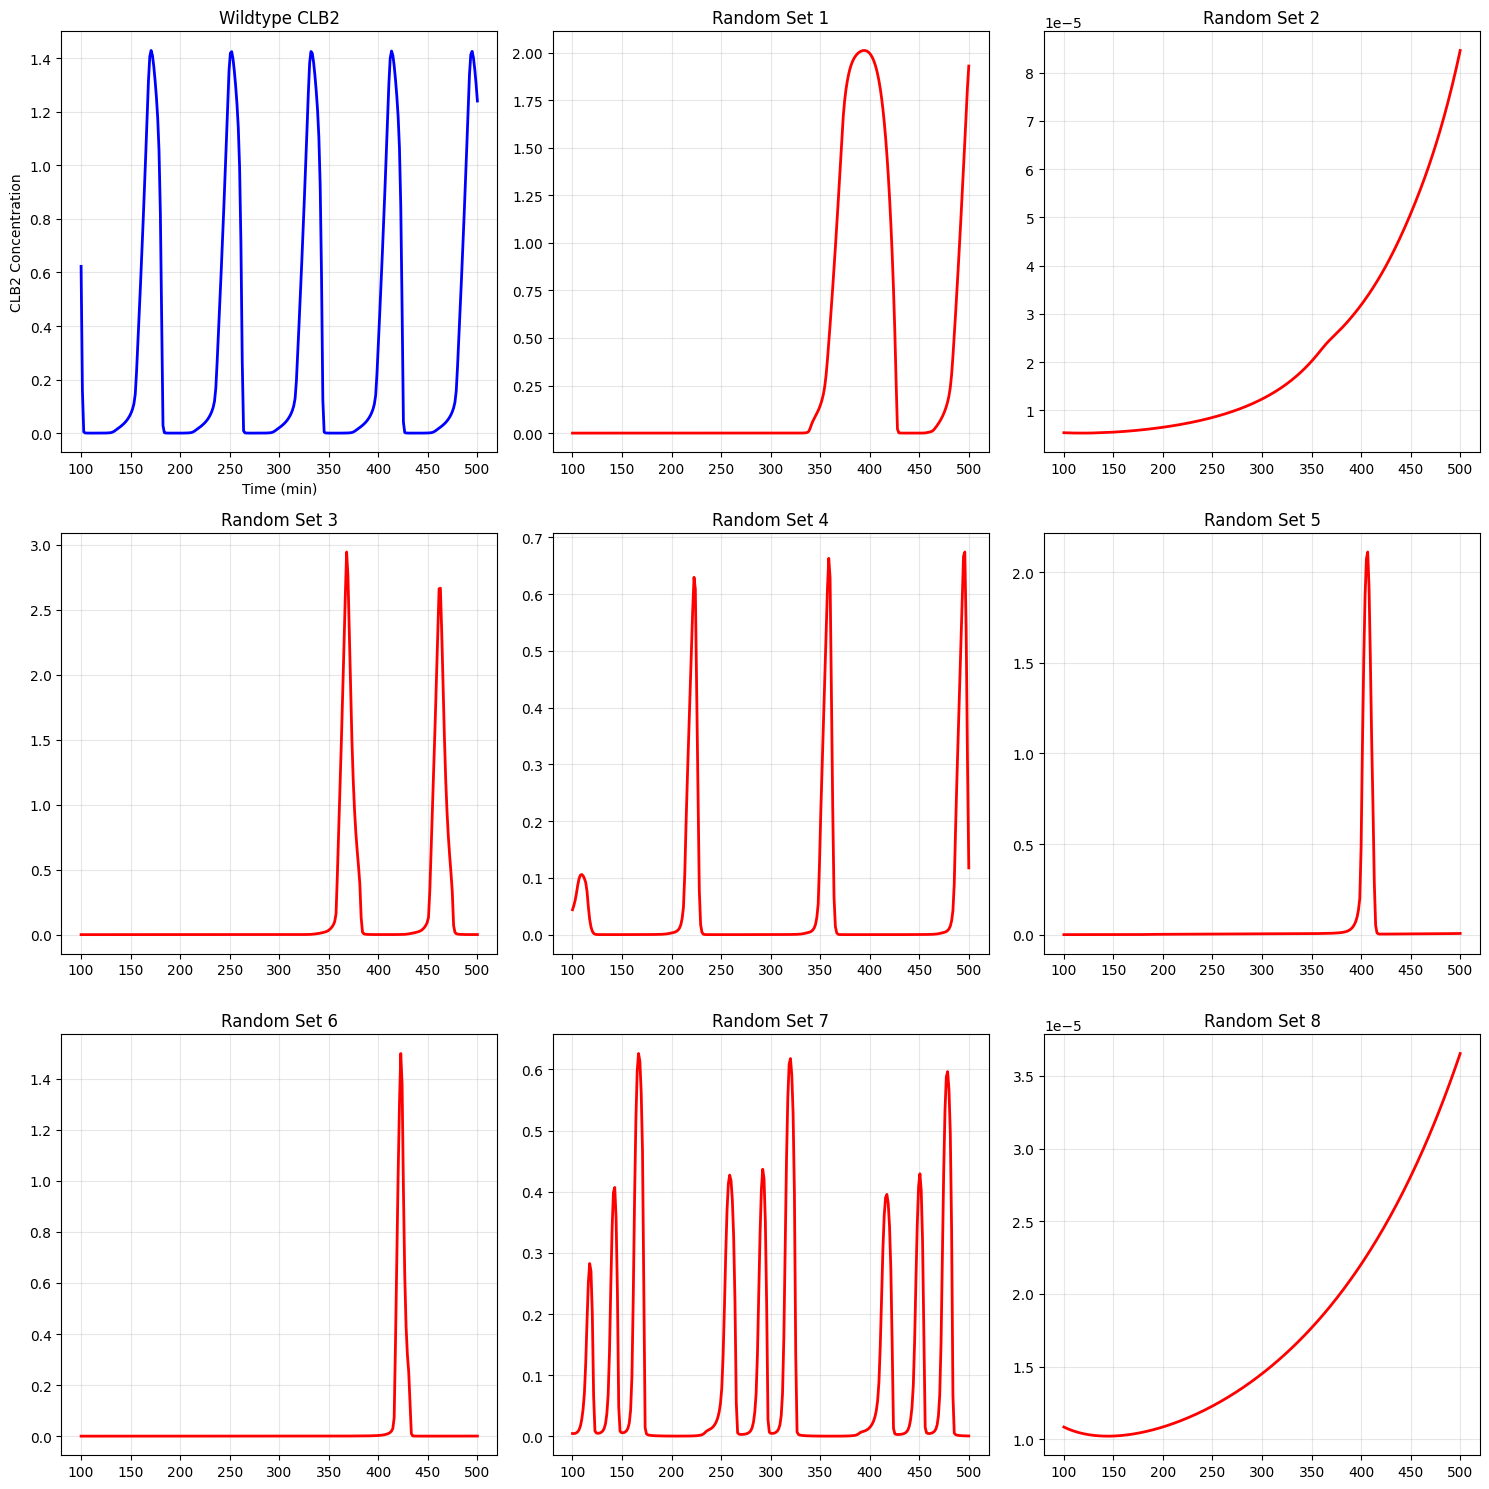

In [277]:
print("Plotting CLB2 trajectories for wildtype and 8 randomized parameter sets...")
TRIES=15
# Create time array
timeplot = np.linspace(SIMULATION_START, SIMULATION_TIME, N_TIME_POINTS + 1)

# Create the plot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.set_layout_engine('constrained')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Simulate and plot wildtype in top-left
rr_wt = te.loadSBMLModel(model_path)

rr_wt.resetAll()
species_wt,_, concentrations_wt = simulate_full_network_fast(rr_wt, CLB2=True)
axes_flat[0].plot(timeplot, concentrations_wt, 'b-', label='CLB2', linewidth=2)
axes_flat[0].set_title("Wildtype CLB2")
axes_flat[0].set_xlabel("Time (min)")
axes_flat[0].set_ylabel("CLB2 Concentration")
axes_flat[0].grid(True, alpha=0.3)

failure_reasons = []
success = False

for i in range(8):
    rr_rand = te.loadSBMLModel(model_path)

    reason = None
    for attempt in range(1, TRIES + 1):
        sample_parameters(rr_rand)    
        species_rand, _, concentrations_rand = simulate_full_network_fast(rr_rand, CLB2=True)
        if species_rand not in [None, "error_runtime", "divergent", "negative", "missing_CLB2"]:
            success = True
            break
        reason = species_rand
    else:
        failure_reasons.append(reason)

    ax = axes_flat[i + 1]
    if concentrations_rand is not None:
        ax.plot(timeplot, concentrations_rand, 'r-', linewidth=2)
        ax.set_title(f"Random Set {i+1}")
    else:
        ax.text(0.5, 0.5, f"Failed: {reason}", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"Random Set {i+1} (failed)")
    ax.grid(True, alpha=0.3)

# if NOTHING worked, replace last subplot with failure histogram
if not success and failure_reasons:
    from collections import Counter
    ax_hist = axes_flat[-1]
    counts = Counter(failure_reasons)
    ax_hist.bar(counts.keys(), counts.values(), color='gray', alpha=0.7)
    ax_hist.set_title("Failure reasons")
    ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Starting parallel data collection with 11 workers...

PARALLEL DATA COLLECTION COMPLETED!
   ⏱️  Total time: 20.4s (0.3m)
   📊 Success: 4,218/10,000 (42.2%)
   🚫 Divergent: 5,782
   ⚠️  Negative: 0
   ⚡ Processing rate: 206.8 samples/s
   📈 Trajectory matrix shape: (4218, 301)
   📈 (samples × features: 4218 × 301)
   🎯 Species: CLB2 only

=== DEBUG INFO ===
Number of species: 1
Species: ['CLB2']...
Number of timepoints: 301
Expected features: 1 species × 301 timepoints = 301
Actual features: 301

raw trajectories shape: (4218, 301)
normalized mean/std: -0.0 1.0
NN dist percentiles: {1: np.float64(2e-06), 5: np.float64(6e-06), 10: np.float64(1.9e-05), 25: np.float64(0.193166), 50: np.float64(1.141361), 75: np.float64(3.061306), 90: np.float64(6.195146), 99: np.float64(17.112292)}


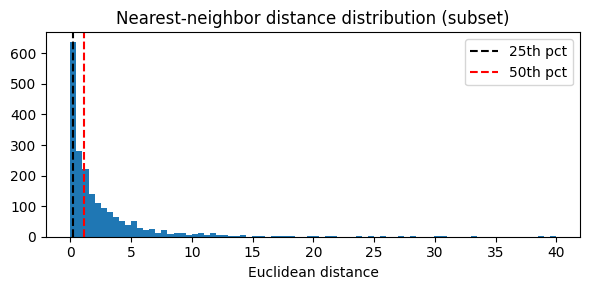

No PCA reduction


In [278]:
network_data =  collect_network_data_parallel(SAMPLE_SIZE)
# # Basic checks
if network_data is None:
    raise ValueError("No network data available. Data collection failed.")
# Add this debug print after collecting data:
print("\n=== DEBUG INFO ===")
if network_data and network_data.get('species_names'):
    print(f"Number of species: {len(network_data['species_names'])}")
    print(f"Species: {network_data['species_names'][:5]}...")
if network_data and network_data.get('time') is not None:
    print(f"Number of timepoints: {len(network_data['time'])}")
print(f"Expected features: {len(network_data['species_names'])} species × {len(network_data['time'])} timepoints = {len(network_data['species_names']) * len(network_data['time'])}")
print(f"Actual features: {network_data['trajectories'].shape[1]}")
print("==================\n")

TRAJECTORIES = network_data['trajectories']
print("raw trajectories shape:", TRAJECTORIES.shape)
n_samples, n_features = TRAJECTORIES.shape

# Standardize (important for Euclidean distance)
if (SCALE):
    scaler = StandardScaler()
    X = scaler.fit_transform(TRAJECTORIES)
    print("normalized mean/std:", np.mean(X).round(4), np.std(X).round(4))
else:
    X=TRAJECTORIES

# Nearest-neighbour distances on subset
subset_idx = np.random.RandomState(RANDOM_STATE).choice(n_samples, size=min(SAMPLE_FOR_NN, n_samples), replace=False)
X_sub = X[subset_idx]

nn = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(X_sub)
dists, _ = nn.kneighbors(X_sub)
first_nn = dists[:, 1]   # distance to nearest other point

percentiles = [1,5,10,25,50,75,90,99]
pvals = np.percentile(first_nn, percentiles)
print("NN dist percentiles:", dict(zip(percentiles, np.round(pvals, 6))))

# quick histogram
plt.figure(figsize=(6,3))
plt.hist(first_nn, bins=80)
plt.axvline(np.percentile(first_nn, 25), color='k', linestyle='--', label='25th pct')
plt.axvline(np.percentile(first_nn, 50), color='r', linestyle='--', label='50th pct')
plt.title("Nearest-neighbor distance distribution (subset)")
plt.xlabel("Euclidean distance")
plt.legend()
plt.tight_layout()
plt.show()

if PCAreduction == True:
    # PCA: either keep 95% variance or fixed n_components (set PCA_N_COMPONENTS accordingly)
    pca = PCA(n_components=PCA_N_COMPONENTS, svd_solver='full', random_state=RANDOM_STATE, whiten=WHITEN)
    X_pca = pca.fit_transform(X)
    print("PCA output shape:", X_pca.shape)
    
    # Show variance cumsum for first components
    var_cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_to_show = min(50, len(var_cumsum))
    print("explained variance cumsum (first {}):".format(n_to_show))
    print(np.round(var_cumsum[:n_to_show], 4))
    
    # --------------------------------------------
    # Create comprehensive PCA visualization
    # --------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # 1. Cumulative variance (linear scale)
    ax1 = axes[0, 0]
    ax1.plot(np.arange(1, len(var_cumsum)+1), var_cumsum, marker='o', markersize=3)
    ax1.axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95% variance')
    ax1.set_xlabel("PC #")
    ax1.set_ylabel("Cumulative explained variance")
    ax1.set_title("Cumulative Explained Variance")
    ax1.grid(alpha=0.3)
    ax1.legend()
    
    # 2. Individual variance per PC (LOG SCALE)
    ax2 = axes[0, 1]
    expl_var = pca.explained_variance_ratio_
    pc_indices = np.arange(1, len(expl_var)+1)
    ax2.semilogy(pc_indices, expl_var, marker='o', markersize=3, label='Explained variance')
    
    # Fit exponential decay line to first 50 components
    n_fit = min(50, len(expl_var))
    log_var = np.log(expl_var[:n_fit])
    coeffs = np.polyfit(pc_indices[:n_fit], log_var, 1)
    decay_rate = coeffs[0]
    fitted_line = np.exp(coeffs[1]) * np.exp(decay_rate * pc_indices[:n_fit])
    ax2.semilogy(pc_indices[:n_fit], fitted_line, 'r--', alpha=0.7, 
                 label=f'Exp fit: decay={decay_rate:.4f}')
    
    ax2.set_xlabel("PC #")
    ax2.set_ylabel("Explained variance (log scale)")
    ax2.set_title("Individual PC Variance (Log Scale)")
    ax2.grid(alpha=0.3, which='both')
    ax2.legend()
    
    # 3. Ratio between consecutive PCs
    ax3 = axes[1, 0]
    n_show = min(50, len(expl_var))
    ratios = expl_var[1:n_show] / expl_var[:n_show-1]
    ax3.plot(np.arange(1, len(ratios)+1), ratios, marker='o', markersize=3)
    geom_mean = np.exp(np.mean(np.log(ratios)))
    ax3.axhline(y=geom_mean, color='r', linestyle='--', alpha=0.5, 
                label=f'Geometric mean: {geom_mean:.3f}')
    ax3.set_xlabel("PC transition k→k+1")
    ax3.set_ylabel("Ratio PC[k+1]/PC[k]")
    ax3.set_title("Decay Rate Between Consecutive PCs")
    ax3.grid(alpha=0.3)
    ax3.legend()
    
    # 4. First N components bar plot (log scale)
    ax4 = axes[1, 1]
    n_bars = min(20, len(expl_var))
    ax4.bar(np.arange(1, n_bars+1), expl_var[:n_bars], alpha=0.7)
    ax4.set_yscale('log')
    ax4.set_xlabel("PC #")
    ax4.set_ylabel("Explained variance (log scale)")
    ax4.set_title(f"First {n_bars} Principal Components")
    ax4.grid(alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    
    # --------------------------------------------
    # Inspect first 10 PCA components and ratios
    # --------------------------------------------
    n_show_text = min(10, len(expl_var))
    print(f"\nFirst {n_show_text} explained variance ratios:")
    for i in range(n_show_text):
        print(f"PC{i+1:2d}: {expl_var[i]:.6e}")
    
    # Compute geometric "common factors" between consecutive PCs
    ratios_text = expl_var[1:n_show_text] / expl_var[:n_show_text-1]
    print("\nRatios (PC[k+1]/PC[k]):")
    for i, r in enumerate(ratios_text, start=1):
        print(f"PC{i}->{i+1}: {r:.3e}")
    
    # Show average multiplicative decay
    geom_mean = np.exp(np.mean(np.log(ratios)))
    print(f"\nApprox. geometric decay factor ≈ {geom_mean:.3e}")
    
    # Additional analysis
    print(f"\n--- Exponential Decay Analysis ---")
    print(f"Decay rate (from log fit): {decay_rate:.6f}")
    print(f"This means each PC explains ~{np.exp(decay_rate)*100:.1f}% of the previous PC")
    
    # Find components needed for different variance thresholds
    for threshold in [0.80, 0.90, 0.95, 0.99]:
        n_needed = np.argmax(var_cumsum >= threshold) + 1
        print(f"Components for {threshold*100:.0f}% variance: {n_needed}")
    
else:
    print("No PCA reduction")

Subset NN percentiles (1,5,10,25,50,75,90,99): [2.0000000e-06 6.0000000e-06 1.9000000e-05 1.9316600e-01 1.1413610e+00
 3.0613060e+00 6.1951460e+00 1.7112292e+01]
Full NN mean 2.155, median 1.053, 75/90/95/99: [ 2.68532174  5.50020494  8.32224543 15.08936978]


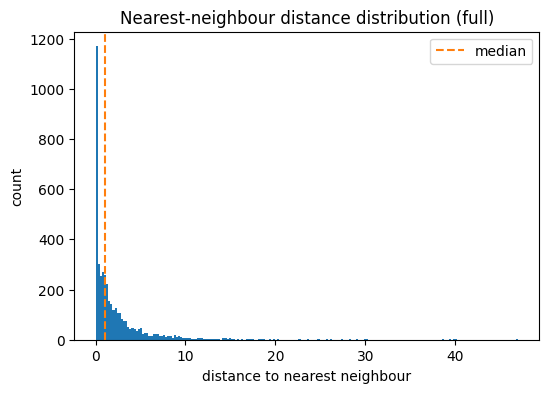

In [279]:
# assume X is standardized (from StandardScaler) and X_pca exists if PCAreduction True
data_for_nn = X_pca if PCAreduction else X   # pick the space to measure distances in

# Quick subsample check (fast)
rng = np.random.RandomState(RANDOM_STATE)
subset_idx = rng.choice(data_for_nn.shape[0], size=min(SAMPLE_FOR_NN, data_for_nn.shape[0]), replace=False)
X_sub = data_for_nn[subset_idx]
nn_sub = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(X_sub)
d_sub, _ = nn_sub.kneighbors(X_sub)
first_nn_sub = d_sub[:, 1]
print("Subset NN percentiles (1,5,10,25,50,75,90,99):",
      np.round(np.percentile(first_nn_sub, [1,5,10,25,50,75,90,99]), 6))

# Full dataset (final)
nn_full = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(data_for_nn)
d_full, _ = nn_full.kneighbors(data_for_nn)
nearest = d_full[:, 1]
print(f"Full NN mean {nearest.mean():.4g}, median {np.median(nearest):.4g},",
      f"75/90/95/99: {np.percentile(nearest, [75,90,95,99])}")

# Plot whichever you like (subsample for clarity, full for final)
plt.figure(figsize=(6,4))
plt.hist(nearest, bins=200)
plt.axvline(np.median(nearest), color='C1', linestyle='--', label='median')
plt.xlabel("distance to nearest neighbour")
plt.ylabel("count")
plt.title("Nearest-neighbour distance distribution (full)")
plt.legend()
plt.show()


Running BIRCH with threshold= 0.21545353744691648
data_for_nn.shape: (4218, 301) X_traj.shape: (4218, 301)
Result: n_clusters = 2931
Largest cluster size: 1100  | singleton clusters: 2835
Sample silhouette score: 0.2189193956683935


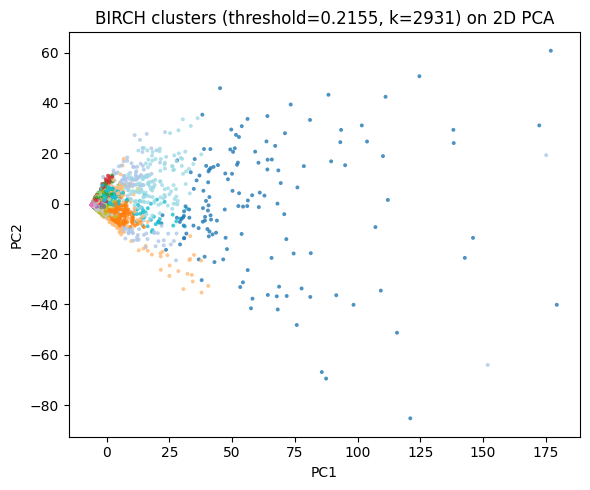

In [285]:
chosen_threshold = 0.1*nearest.mean()
print("Running BIRCH with threshold=", chosen_threshold)
birch = Birch(n_clusters=None, threshold=chosen_threshold, branching_factor=BRANCHING_FACTOR)
cluster_labels = birch.fit_predict(data_for_nn)
n_clusters = len(np.unique(cluster_labels))
print("data_for_nn.shape:", data_for_nn.shape, "X_traj.shape:", X_traj.shape)

print("Result: n_clusters =", n_clusters)
counts = Counter(cluster_labels)
print("Largest cluster size:", max(counts.values()), " | singleton clusters:", sum(1 for c in counts.values() if c==1))

# Sample silhouette (if many samples, compute on a random sample)
if data_for_nn.shape[0] > N_SILHOUETTE_SAMPLE:
    idx_sample = np.random.RandomState(RANDOM_STATE).choice(data_for_nn.shape[0], N_SILHOUETTE_SAMPLE, replace=False)
else:
    idx_sample = np.arange(data_for_nn.shape[0])

s = silhouette_score(data_for_nn[idx_sample], cluster_labels[idx_sample])
print("Sample silhouette score:", s)

# Visualize with 2D PCA projection (for intuition)
from sklearn.decomposition import PCA as PCAsmall
proj2 = PCAsmall(n_components=2, random_state=RANDOM_STATE).fit_transform(data_for_nn)
plt.figure(figsize=(6,5))
sc = plt.scatter(proj2[:,0], proj2[:,1], c=cluster_labels, s=8, cmap='tab20', linewidths=0, alpha=0.8)
plt.title(f"BIRCH clusters (threshold={chosen_threshold:.4g}, k={n_clusters}) on 2D PCA")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Clusters with >=2 members: 96 out of 2931


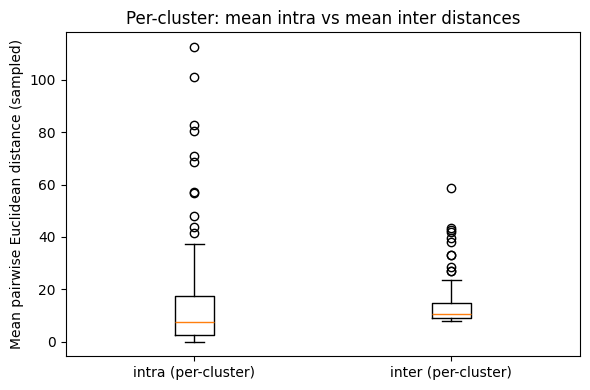

Wilcoxon paired test: stat=1.74e+03, p=0.0305 (intra < inter?)


In [286]:
def sample_pairwise_distances(X, idx_pairs):
    # idx_pairs is array of shape (n_pairs, 2)
    # returns distances
    return np.linalg.norm(X[idx_pairs[:,0]] - X[idx_pairs[:,1]], axis=1)

# Precompute indices by cluster
labels = cluster_labels
unique_labels = np.unique(labels)
label_to_idx = {lab: np.where(labels == lab)[0] for lab in unique_labels}

# For each cluster, sample up to K intra pairs and up to K inter pairs (between that cluster and random other points)
K = 2000  # pairs per cluster for sampling; reduce if slow
rng = np.random.RandomState(RANDOM_STATE)

intra_means = []
inter_means = []
cluster_sizes = []
pairwise_samples_intra = []
pairwise_samples_inter = []

for lab in unique_labels:
    idx = label_to_idx[lab]
    m = len(idx)
    cluster_sizes.append(m)
    if m < 2:
        intra_means.append(np.nan)
        inter_means.append(np.nan)
        pairwise_samples_intra.append([])
        pairwise_samples_inter.append([])
        continue

    # sample intra-cluster pairs
    n_pairs_intra = min(K, m*(m-1)//2)
    # generate random pairs
    pairs = []
    while len(pairs) < n_pairs_intra:
        a = rng.choice(idx, size=n_pairs_intra, replace=True)
        b = rng.choice(idx, size=n_pairs_intra, replace=True)
        mask = a != b
        pair_batch = np.vstack((a[mask], b[mask])).T
        pairs.extend(pair_batch.tolist())
        if len(pairs) > n_pairs_intra:
            pairs = pairs[:n_pairs_intra]
    pairs = np.array(pairs)
    d_intra = sample_pairwise_distances(X_pca, pairs)
    pairwise_samples_intra.append(d_intra)
    intra_means.append(np.mean(d_intra))

    # sample inter-cluster pairs (take one from cluster, one outside)
    outside_idx = np.setdiff1d(np.arange(X_pca.shape[0]), idx)
    n_pairs_inter = min(K, m * min(K, len(outside_idx)))
    a = rng.choice(idx, size=n_pairs_inter, replace=True)
    b = rng.choice(outside_idx, size=n_pairs_inter, replace=True)
    pairs_inter = np.vstack((a,b)).T
    d_inter = sample_pairwise_distances(X_pca, pairs_inter)
    pairwise_samples_inter.append(d_inter)
    inter_means.append(np.mean(d_inter))

# Convert to arrays for plotting
cluster_sizes = np.array(cluster_sizes)
intra_means = np.array(intra_means)
inter_means = np.array(inter_means)

# Filter clusters with enough points
valid = ~np.isnan(intra_means)
print("Clusters with >=2 members:", valid.sum(), "out of", len(unique_labels))

# Plot distribution of intra vs inter mean distances
plt.figure(figsize=(6,4))
plt.boxplot([intra_means[valid], inter_means[valid]], labels=['intra (per-cluster)', 'inter (per-cluster)'])
plt.ylabel("Mean pairwise Euclidean distance (sampled)")
plt.title("Per-cluster: mean intra vs mean inter distances")
plt.tight_layout()
plt.show()

# Paired test: are intra means smaller than inter means?
stat, pval = stats.wilcoxon(intra_means[valid], inter_means[valid])
print(f"Wilcoxon paired test: stat={stat:.3g}, p={pval:.3g} (intra < inter?)")


X_traj.shape: (4218, 301)
labels.shape: (4218,)
len(unique_labels): 2931
labels dtype: int64
labels min/max: 0 2930
No offending label found in sample subset — check full loop if needed.
Clusters with >=2 members: 96 out of 2931


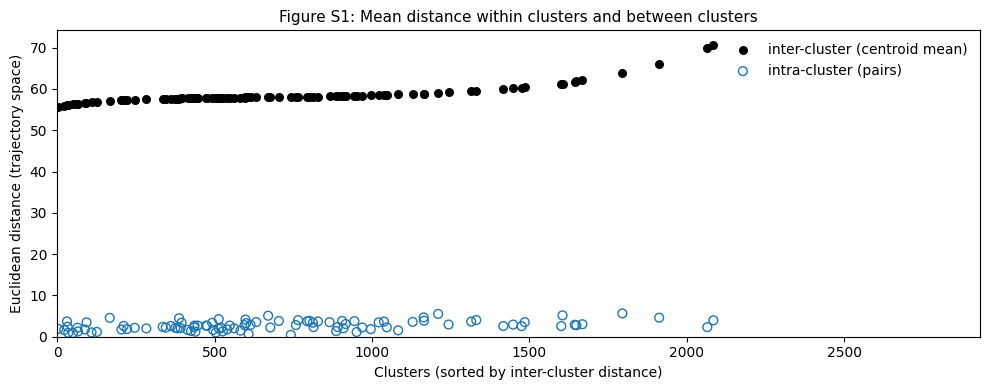

1398.892937167448
5.638897468207971


In [287]:


# ---------- Inputs (must exist) ----------
# trajectories: (n_samples, n_features) flattened mn-tuples (trajectory space)
# cluster_labels: 1D array of length n_samples with microcluster label for each sample
# If you used different names, replace them here.

X_traj = TRAJECTORIES  # (n_samples, n_features)
labels = cluster_labels
unique_labels = np.unique(labels)

# ---------- Parameters ----------
K_MAX_PAIRS = 2000   # max pairs to sample for intra-cluster distances (speed)
RNG = np.random.RandomState(0)

# ---------- Helpers ----------
def sample_intra_pairwise_mean(X, idx, max_pairs=K_MAX_PAIRS, rng=RNG):
    """Return mean and standard error of pairwise distances within X[idx]."""
    m = len(idx)
    if m < 2:
        return np.nan, np.nan, 0
    # if small, compute all pairs exactly
    if m*(m-1)//2 <= max_pairs:
        # all pairs
        ii, jj = np.triu_indices(m, k=1)
        pairs = np.vstack((idx[ii], idx[jj])).T
    else:
        # sample random unequal pairs
        n = max_pairs
        a = rng.choice(idx, size=n, replace=True)
        b = rng.choice(idx, size=n, replace=True)
        mask = a != b
        a = a[mask]
        b = b[mask]
        # if still >n, truncate
        pairs = np.vstack((a[:n], b[:n])).T

    diffs = X_traj[pairs[:,0]] - X_traj[pairs[:,1]]
    dists = np.linalg.norm(diffs, axis=1)
    mean = dists.mean() if len(dists) > 0 else np.nan
    stderr = dists.std(ddof=1)/math.sqrt(len(dists)) if len(dists) > 1 else 0.0
    return mean, stderr, len(dists)

# ---------- Compute cluster centroids ----------
label_to_idx = {lab: np.where(labels == lab)[0] for lab in unique_labels}
print("X_traj.shape:", X_traj.shape)
print("labels.shape:", np.shape(labels))
print("len(unique_labels):", len(unique_labels))
print("labels dtype:", labels.dtype)
print("labels min/max:", np.min(labels), np.max(labels))

# find offending label(s) whose index positions exceed X_traj rows
for lab in unique_labels[:50]:      # sample first 50 labels
    idx = np.where(labels == lab)[0]
    if idx.size > 0 and idx.max() >= X_traj.shape[0]:
        print("BAD LABEL", lab, "-> idx.max()", idx.max())
        break
else:
    print("No offending label found in sample subset — check full loop if needed.")


centroids = []
for lab in unique_labels:
    idx = label_to_idx[lab]
    if len(idx) == 0:
        centroids.append(np.full(X_traj.shape[1], np.nan))
    else:
        centroids.append(X_traj[idx].mean(axis=0))
centroids = np.vstack(centroids)  # shape: (n_clusters, n_features)

# ---------- Compute per-cluster intra means and SE ----------
intra_means = np.empty(len(unique_labels))
intra_se = np.empty(len(unique_labels))
intra_npairs = np.empty(len(unique_labels), dtype=int)
for i, lab in enumerate(unique_labels):
    idx = label_to_idx[lab]
    if len(idx) < 2:
        intra_means[i] = np.nan
        intra_se[i] = np.nan
        intra_npairs[i] = 0
    else:
        m, se, n_pairs = sample_intra_pairwise_mean(X_traj, idx, max_pairs=K_MAX_PAIRS, rng=RNG)
        intra_means[i] = m
        intra_se[i] = se
        intra_npairs[i] = n_pairs

# ---------- Compute per-cluster inter means (centroid-to-centroid mean) ----------
# Distance matrix between centroids
# (ignore centroids that are nan)
valid_centroid_mask = ~np.isnan(centroids).any(axis=1)
centroids_valid = centroids[valid_centroid_mask]
d_cent = cdist(centroids_valid, centroids_valid, metric='euclidean')  # square matrix

# map back: for each original unique_labels index, compute mean dist from its centroid to others
inter_means = np.empty(len(unique_labels))
inter_se = np.empty(len(unique_labels))
for i, lab in enumerate(unique_labels):
    if not valid_centroid_mask[i]:
        inter_means[i] = np.nan
        inter_se[i] = np.nan
        continue
    # index among valid centroids
    valid_idx = np.where(valid_centroid_mask)[0].tolist().index(i)
    row = d_cent[valid_idx]
    # exclude self (zero distance)
    others = row[row > 0]
    if len(others) == 0:
        inter_means[i] = np.nan
        inter_se[i] = np.nan
    else:
        inter_means[i] = others.mean()
        inter_se[i] = others.std(ddof=1) / math.sqrt(len(others))

# ---------- Filter clusters with at least 2 members ----------
has_data = (~np.isnan(intra_means)) & (~np.isnan(inter_means))
print("Clusters with >=2 members:", np.count_nonzero(has_data), "out of", len(unique_labels))

# ---------- Sort clusters by inter-cluster mean (ascending) ----------
order = np.argsort(inter_means)
inter_sorted = inter_means[order]
intra_sorted = intra_means[order]
inter_se_sorted = inter_se[order]
intra_se_sorted = intra_se[order]
cluster_sizes = np.array([len(label_to_idx[lab]) for lab in unique_labels])[order]

# optionally restrict to clusters with >=2 members for plotting points
valid_idx_for_plot = np.where(~np.isnan(intra_sorted))[0]

# ---------- Plot (Figure S1 style) ----------
plt.figure(figsize=(10,4))
x = np.arange(len(unique_labels))  # horizontal positions for clusters

# plot inter-cluster closed circles
plt.scatter(x[valid_idx_for_plot], inter_sorted[valid_idx_for_plot],
            marker='o', facecolors='black', edgecolors='black', s=30, label='inter-cluster (centroid mean)')

# plot intra-cluster open circles
plt.scatter(x[valid_idx_for_plot], intra_sorted[valid_idx_for_plot],
            marker='o', facecolors='none', edgecolors='tab:blue', s=40, label='intra-cluster (pairs)')

# styling & labels
plt.xlabel("Clusters (sorted by inter-cluster distance)", fontsize=10)
plt.ylabel("Euclidean distance (trajectory space)", fontsize=10)
plt.title("Figure S1: Mean distance within clusters and between clusters", fontsize=11)
plt.xlim(-1, len(unique_labels))
plt.ylim(0, max(np.nanmax(inter_sorted[valid_idx_for_plot]), np.nanmax(intra_sorted[valid_idx_for_plot])) * 1.05)
plt.legend(frameon=False)
plt.tight_layout()

plt.show()
print(np.nanmax(inter_sorted))
print(np.nanmax(intra_sorted))

# ---------- (Optional) Save figure ----------
# plt.savefig("Figure_S1_mean_distances.png", dpi=300, bbox_inches='tight')


Species names: ['CLB2']
CLB2_Only=False → plotting 1 random species.
Plotting 12 phenotypes for 1 species.
Plotting phenotypes for species: CLB2


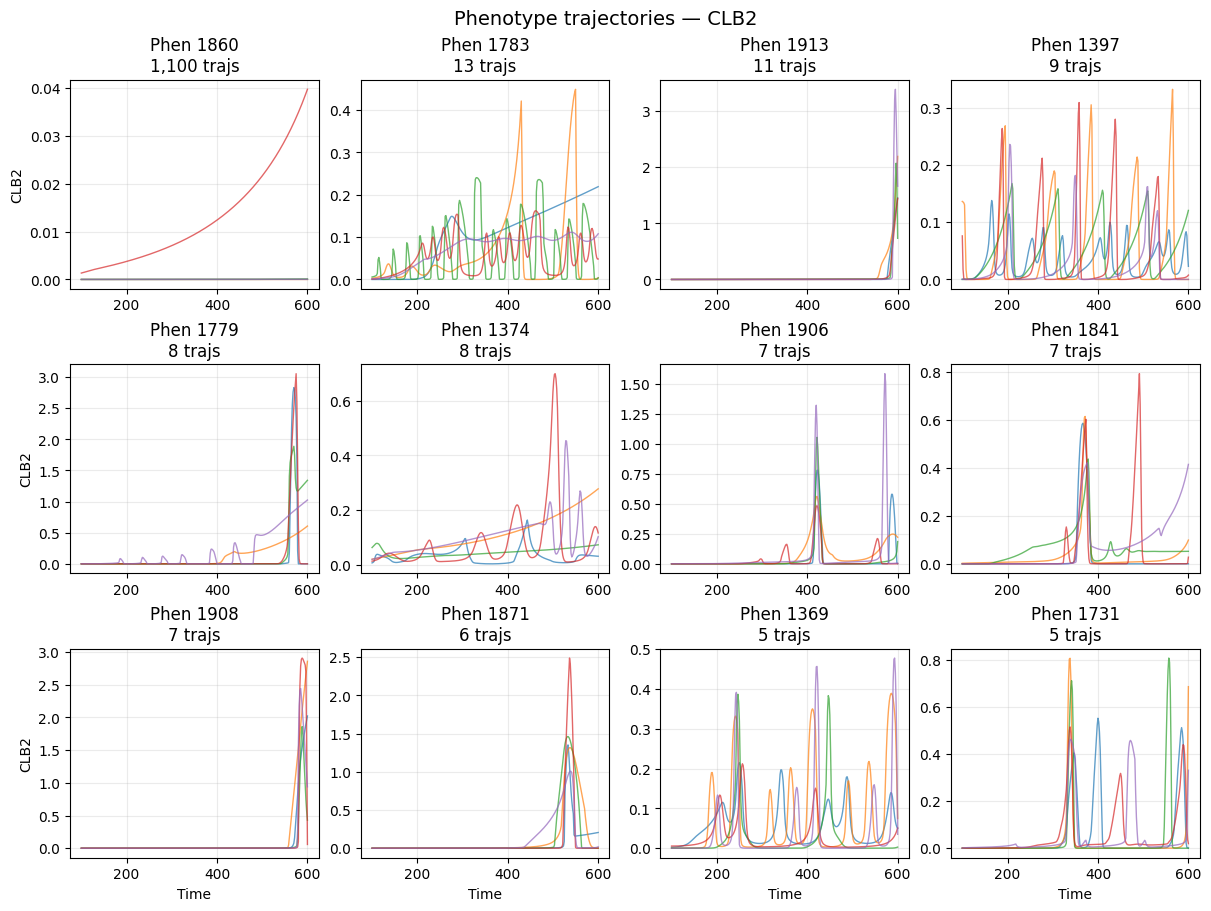

✓ Phenotype visualization complete for all selected species.


In [288]:
# === VISUALIZATION OF PHENOTYPES ===
# --- Parameters ---
TOP_N_CL = 12        # number of phenotypes (clusters) to show (largest)
TRAJ_PER_CL = 5      # number of trajectories to overlay per phenotype
SPECIES_TO_PLOT = 1  # int = random number of species, list = specific indices, None = all
ALPHA = 0.7          # line transparency

# --- Retrieve everything needed for plotting ---
final_labels  = cluster_labels                  # cluster labels (1D)
trajectories  = network_data['trajectories']    # flattened trajectories
species_names = network_data['species_names']   # species identifiers
print("Species names:", species_names)

# --- Layout and figure parameters ---
MAX_PHEN_COLS = 4
FIG_WIDTH_PER_COL = 3
FIG_HEIGHT_PER_ROW = 3
Tplot = True
RNG_SEED = None

# ============================================================
# === PLOTTING CODE (no variable definitions inside) ==========
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math

rng = np.random.default_rng(RNG_SEED)

# reshape trajectories
n_samples, total_features = trajectories.shape
if len(species_names) == 1:
    n_species = 1
    N_TIMEPOINTS = total_features
    trajectories = trajectories.reshape(n_samples, N_TIMEPOINTS, 1)
else:
    n_species = len(species_names)
    N_TIMEPOINTS = total_features // n_species
    trajectories = trajectories.reshape(n_samples, N_TIMEPOINTS, n_species)

timepoints = np.linspace(SIMULATION_START, SIMULATION_START + SIMULATION_TIME, N_TIMEPOINTS)

# choose top phenotypes by size
phen_counts = Counter(final_labels)
sorted_phens = [p for p, _ in sorted(phen_counts.items(), key=lambda x: x[1], reverse=True)]
phen_list = sorted_phens[:TOP_N_CL]
if len(phen_list) < TOP_N_CL:
    print(f"Only {len(phen_list)} unique phenotypes available (requested {TOP_N_CL}).")

# select which species to plot
# ============================================================
# === Species selection logic ================================
# ============================================================

if 'CLB2_Only' in globals() and CLB2_Only:
    # Force CLB2 only
    if "CLB2" in species_names:
        species_indices = [species_names.index("CLB2")]
        print("CLB2_Only=True → plotting only CLB2.")
    else:
        raise ValueError("CLB2_Only=True but 'CLB2' not found in species_names.")
else:
    # Randomly choose N species (N = SPECIES_TO_PLOT)
    if isinstance(SPECIES_TO_PLOT, int):
        n_to_plot = min(SPECIES_TO_PLOT, len(species_names))
        species_indices = rng.choice(np.arange(len(species_names)), size=n_to_plot, replace=False)
    elif SPECIES_TO_PLOT is None:
        species_indices = np.arange(len(species_names))
    else:
        species_indices = np.array(SPECIES_TO_PLOT, ndmin=1)
    print(f"CLB2_Only=False → plotting {len(species_indices)} random species.")

n_phen = len(phen_list)
n_species_to_plot = len(species_indices)
print(f"Plotting {n_phen} phenotypes for {n_species_to_plot} species.")

# grid layout
cols = min(MAX_PHEN_COLS, n_phen)
rows_per_species = math.ceil(n_phen / cols)
total_rows = n_species_to_plot * rows_per_species
total_cols = cols
fig_w = FIG_WIDTH_PER_COL * total_cols
fig_h = FIG_HEIGHT_PER_ROW * total_rows




# ============================================================
# === Plotting logic (looped if multiple species) ============
# ============================================================

if not Tplot:
    print("Tplot=False — skipping plot creation.")
else:
    for s_idx in species_indices:
        sp_label = species_names[s_idx]
        print(f"Plotting phenotypes for species: {sp_label}")

        cols = min(MAX_PHEN_COLS, len(phen_list))
        rows = math.ceil(len(phen_list) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(FIG_WIDTH_PER_COL * cols, FIG_HEIGHT_PER_ROW * rows), squeeze=False)
        fig.set_layout_engine('constrained')

        for i, phen in enumerate(phen_list):
            row = i // cols
            col = i % cols
            ax = axes[row, col]

            idxs = np.where(final_labels == phen)[0]
            if len(idxs) == 0:
                ax.axis('off')
                continue

            chosen = rng.choice(idxs, size=min(TRAJ_PER_CL, len(idxs)), replace=False)
            for samp in chosen:
                ax.plot(timepoints, trajectories[samp, :, s_idx], '-', alpha=ALPHA, linewidth=1)

            ax.grid(True, alpha=0.25)
            ax.set_title(f"Phen {phen}\n{phen_counts[phen]:,} trajs")
            if row == rows - 1:
                ax.set_xlabel("Time")
            if col == 0:
                ax.set_ylabel(sp_label)

        # turn off unused axes
        for j in range(len(phen_list), rows * cols):
            r, c = divmod(j, cols)
            axes[r, c].axis('off')

        plt.suptitle(f"Phenotype trajectories — {sp_label}", fontsize=14)
        plt.show(block=False)
        plt.pause(0.1)

    print("✓ Phenotype visualization complete for all selected species.")



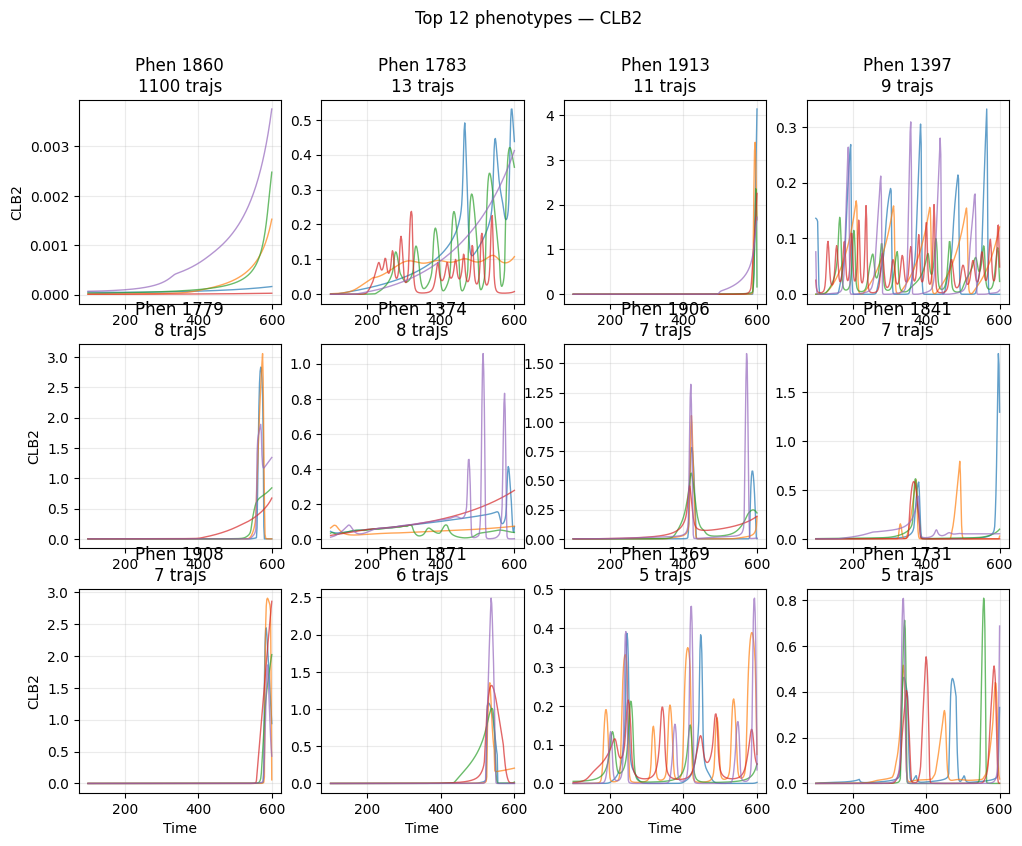

In [289]:
# --- Plot top 12 largest clusters quickly ---
top_phens = [p for p,_ in sorted(Counter(final_labels).items(), key=lambda x:x[1], reverse=True)[:12]]

for s_idx in species_indices:
    sp = species_names[s_idx]
    fig, axes = plt.subplots(math.ceil(len(top_phens)/MAX_PHEN_COLS), MAX_PHEN_COLS,
                             figsize=(FIG_WIDTH_PER_COL*MAX_PHEN_COLS, FIG_HEIGHT_PER_ROW*math.ceil(len(top_phens)/MAX_PHEN_COLS)),
                             squeeze=False)
    for i, ph in enumerate(top_phens):
        r, c = divmod(i, MAX_PHEN_COLS)
        ax = axes[r, c]
        ids = np.where(final_labels == ph)[0]
        if len(ids) == 0: ax.axis('off'); continue
        for t in rng.choice(ids, size=min(TRAJ_PER_CL, len(ids)), replace=False):
            ax.plot(timepoints, trajectories[t,:,s_idx], '-', alpha=ALPHA, lw=1)
        ax.set_title(f"Phen {ph}\n{len(ids)} trajs")
        if r == len(axes)-1: ax.set_xlabel("Time")
        if c == 0: ax.set_ylabel(sp)
        ax.grid(True, alpha=0.25)
    for j in range(len(top_phens), len(axes)*MAX_PHEN_COLS):
        r, c = divmod(j, MAX_PHEN_COLS); axes[r,c].axis('off')
    plt.suptitle(f"Top 12 phenotypes — {sp}")
    plt.show()
